In [1]:
# importing required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# check that TensorFlow sees your GPU.
# If a GPU is listed, Keras will automatically use it during training.
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# loading dataset --> Fashion-MNIST = 28x28 grayscale clothing images, 10 classes.
fashion_mnist = keras.datasets.fashion_mnist

# train_images: (60000, 28, 28), train_labels: (60000,)
# test_images:  (10000, 28, 28), test_labels:  (10000,)
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [6]:
# Split into train, val and test sets.

# First, split original train set into (train + validation).
# For example: 50,000 for training, 10,000 for validation.
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images,
    train_labels,
    test_size=10000,      # 10k for validation
    random_state=42,
    stratify=train_labels # keep label distribution similar.
)

print("Train image:", train_images.shape, train_labels.shape)
print("Val image:",   val_images.shape, val_labels.shape)
print("Test image:",  test_images.shape, test_labels.shape)

Train image: (50000, 28, 28) (50000,)
Val image: (10000, 28, 28) (10000,)
Test image: (10000, 28, 28) (10000,)


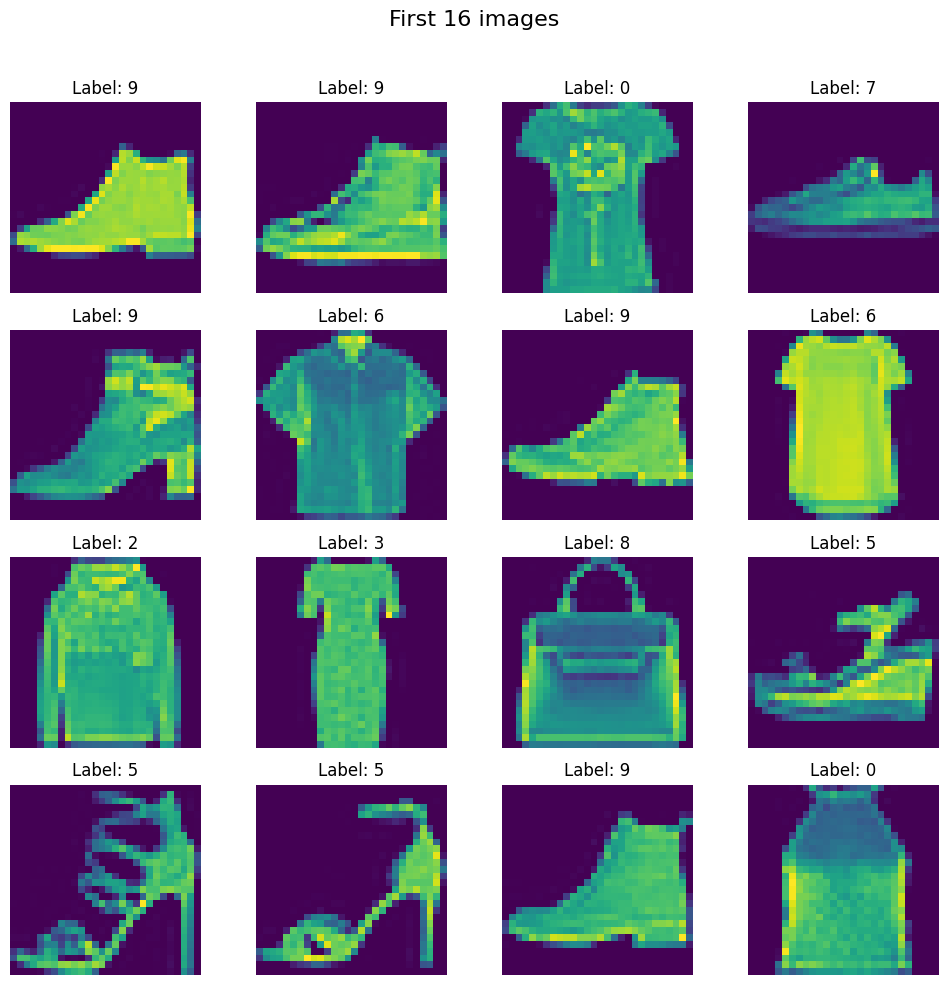

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle("First 16 images", fontsize=16)


# plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
  img = train_images[i]
  ax.imshow(img) # Display in grayscale
  ax.axis("off")  # Remove axis for a cleaner look
  ax.set_title(f"Label: {str(train_labels[i])}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [8]:
# CNNs usually work better when input pixels are normalized to [0, 1].
# Original pixel values are 0–255 (uint8), so we convert to float32 and divide by 255.
train_images = train_images.astype("float32") / 255.0
val_images = val_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Current shape is (batch, 28, 28). CNN layers expect (batch, height, width, channels).
# Because images are grayscale, channels = 1.
train_images = train_images[..., tf.newaxis]  # becomes (50000, 28, 28, 1)
val_images = val_images[..., tf.newaxis]  # becomes (10000, 28, 28, 1)
test_images = test_images[..., tf.newaxis]    # becomes (10000, 28, 28, 1)

print("Train images reshaped:", train_images.shape)
print("Train images reshaped:", val_images.shape)
print("Test images reshaped:", test_images.shape)

# Labels are integers 0–9, so we can keep them as int and use sparse_categorical_crossentropy.
num_classes = 10

Train images reshaped: (50000, 28, 28, 1)
Train images reshaped: (10000, 28, 28, 1)
Test images reshaped: (10000, 28, 28, 1)


In [9]:
batch_size = 64

# Create a Dataset from the NumPy arrays.
# This makes it easy to shuffle, batch, and prefetch (good for GPU pipelines).
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

# Shuffle the training data so each epoch sees batches in a different order.
# Then batch into groups and prefetch to keep GPU fed with data.
train_ds = (
    train_ds
    .shuffle(buffer_size=len(train_images))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation and Test data does not need shuffling, just batching and prefetching.
val_ds  = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [10]:
# We use Sequential because this CNN is a simple "stack" of layers.
model = keras.Sequential(
    [
        # input layer to define input shape
        layers.Input(shape=(28, 28, 1)), # input size: 28x28 grayscale

        # First convolutional block:
        # Conv2D learns small 3x3 filters that slide over the image to detect local patterns
        # like edges, corners, simple textures.
        layers.Conv2D(
            filters=32,              # number of filters (feature maps)
            kernel_size=(3, 3),      # height and width of each filter
            activation="relu",       # non-linear activation to add capacity
            #input_shape=(28, 28, 1), # input size: 28x28 grayscale
            name="conv1",
        ),
        # MaxPooling2D downsamples the feature maps by taking the max in each 2x2 window.
        # This reduces spatial size (computations) and makes features more robust to small shifts.
        layers.MaxPooling2D(pool_size=(2, 2), name="pool1"),

        # Second convolutional block:
        # Here we increase filters to 64 to learn more complex patterns.
        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            name="conv2",
        ),
        layers.MaxPooling2D(pool_size=(2, 2), name="pool2"),

        # Flatten converts the 2D feature maps into a 1D vector so we can feed it
        # into a standard Dense (fully-connected) layer.
        layers.Flatten(name="flatten"),

        # Dense hidden layer learns non-linear combinations of the extracted features.
        layers.Dense(128, activation="relu", name="dense1"),

        # Output layer: 10 units (one per clothing class), softmax for probabilities.
        layers.Dense(num_classes, activation="softmax", name="predictions"),
    ])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# For multi-class classification with integer labels 0–9,
# we use sparse_categorical_crossentropy.
model.compile(
    optimizer="adam",                          # adaptive learning rate optimizer (good default)
    loss="sparse_categorical_crossentropy",    # suitable for int labels with softmax output
    metrics=["accuracy"],                      # we care about classification accuracy
)

In [12]:
# Fit the model on the training dataset.
# If a GPU is available, Keras will automatically run the heavy ops on GPU.
epochs = 10

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,  # use test set as validation
    verbose=2,
)

Epoch 1/10
782/782 - 9s - 12ms/step - accuracy: 0.8184 - loss: 0.5074 - val_accuracy: 0.8578 - val_loss: 0.3800
Epoch 2/10
782/782 - 3s - 3ms/step - accuracy: 0.8795 - loss: 0.3348 - val_accuracy: 0.8926 - val_loss: 0.2979
Epoch 3/10
782/782 - 3s - 3ms/step - accuracy: 0.8968 - loss: 0.2859 - val_accuracy: 0.8930 - val_loss: 0.2934
Epoch 4/10
782/782 - 3s - 4ms/step - accuracy: 0.9078 - loss: 0.2522 - val_accuracy: 0.9063 - val_loss: 0.2659
Epoch 5/10
782/782 - 5s - 7ms/step - accuracy: 0.9162 - loss: 0.2261 - val_accuracy: 0.9088 - val_loss: 0.2504
Epoch 6/10
782/782 - 3s - 3ms/step - accuracy: 0.9231 - loss: 0.2056 - val_accuracy: 0.9088 - val_loss: 0.2586
Epoch 7/10
782/782 - 3s - 4ms/step - accuracy: 0.9304 - loss: 0.1870 - val_accuracy: 0.9070 - val_loss: 0.2586
Epoch 8/10
782/782 - 3s - 4ms/step - accuracy: 0.9379 - loss: 0.1677 - val_accuracy: 0.9219 - val_loss: 0.2324
Epoch 9/10
782/782 - 3s - 4ms/step - accuracy: 0.9450 - loss: 0.1500 - val_accuracy: 0.9080 - val_loss: 0.2635


In [13]:
# Evaluate final performance on the test set.
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

157/157 - 0s - 2ms/step - accuracy: 0.9065 - loss: 0.2738
Test loss: 0.27380305528640747
Test accuracy: 0.906499981880188
